In [1]:
# ============================================================
# CELL 1 – Imports
# ============================================================
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
# ============================================================
# CELL 2 – Load data
# ============================================================
data       = pd.read_csv("Nicaragua_Data.csv")
C_raw_NTU  = data["Turbiedad (UNT)"].values    # raw turbidity  [NTU]
C_coag_mgL = data["Dosis (mg/L)"].values       # coagulant dose [mg/L as Al]
N          = len(C_raw_NTU)

print(f"Loaded {N} data points")
print(f"  Turbidity : {C_raw_NTU.min():.1f} – {C_raw_NTU.max():.1f} NTU")
print(f"  Dose      : {C_coag_mgL.min():.2f} – {C_coag_mgL.max():.2f} mg/L")

Loaded 37 data points
  Turbidity : 1.9 – 650.0 NTU
  Dose      : 6.00 – 35.00 mg/L


In [198]:
# ============================================================
# CELL 3 – Configuration
# Edit values here
# ============================================================

# ── Training ─────────────────────────────────────────────────
EPOCHS    = 4000
LR        = 3e-3
LOG_EVERY = 400
SEED      = 42

# ── Design target ─────────────────────────────────────────────
# The Nicaragua plant was dosing to achieve roughly 1 NTU clarified water.
# Adjust this if you know the actual plant target.
C_TARGET_NTU = 1.0   # [NTU]

# ── Unit conversion ───────────────────────────────────────────
NTU_TO_KG_M3  = 1.47e-3   # [kg/m³ per NTU]
                          # 1 NTU ≈ 1.47 mg/L for kaolinite (68 NTU ≈ 100 mg/L kaolinite)
                          # Source: Wei et al., 2015
                          # https://doi.org/10.1016/j.cjche.2015.02.003
MGL_TO_KG_M3  = 1.0e-3    # [kg/m³ per mg/L]
                          # 1 mg/L = 1e-3 g/L = 1e-3 kg/m³

# ── Fixed physical constants (SI units) ───────────────────────
PI      = math.pi
RHO_P   = 2600.0        # kg/m³  – primary particle (clay) density
                        # Source: https://amp.chemicalbook.com/ChemicalProductProperty_EN_CB6300504.htm
RHO_C   = 1138.0        # kg/m³  – coagulant nanoparticle (PACl) density
                        # Source: 
H_FF    = 1.0           # m      – floc filter / floc blanket height
THETA_T = 15 * 60.0     # s      - HRT of flocculator
G       = 39.0          # 1/s    - velocity gradient
                        # 15 minutes for theta, 35,000 for G-theta -> 39 for G
                        # Source: Monroe Weber-Shirk
R_P     = 3.5e-6        # m      - primary particle (clay) radius
                        # Source: Sun et al., 2015
                        # https://journals.sagepub.com/doi/full/10.1089/ees.2015.0311
R_C     = 45.0e-9       # [m]   - coagulant nanoparticle radius
                        # Source: Pennock et al., 2018
                        # https://journals.sagepub.com/doi/epub/10.1089/ees.2017.0332
PHI_FLOC = 0.15         # (dimensionless) - floc volume fraction in floc filter
                        # Source: Hurst, 2010
                        # https://ecommons.cornell.edu/server/api/core/bitstreams/18349e07-0892-4d45-b174-aab93d396760/content

# ── Initial parameter values (SI units: m, kg, s) ─────────────
INIT = {
    "k"              : 0.66,    #  flocculation fitting constant  (dimensionless)
    # "r_floc"         : 1.0e-3,  # floc radius in clarifier       [m] = 1 mm
    # "C_floc_blanket" : 2.0,     # floc blanket concentration     [kg/m³] ≈ 2 g/L
                                # (textbook: typical 1–5 g/L)
    "Lambda"         : 1.0e-2,  # Floc separation distance        [m] = 1 cm
    "C_dom"          : 1.0e-3,  # DOM concentration              [kg/m³]
    "SA_V_flocculator" : 2.0,     # Surface area to volume ratio of flocculator [m^-1]
}

In [212]:
# ============================================================
# CELL 4 – Model
# ============================================================
def floc_clarify_model(C_raw_mass, C_coag_mass, params):
    """
    params : dict with keys 'k', 'Lambda', 'C_dom', 'SA_V_flocculator'  (SI units, positive)
    """
    k                   = params["k"]
    Lambda              = params["Lambda"]
    C_dom               = params["C_dom"]
    SA_V_flocculator    = params["SA_V_flocculator"]

    # ── STEP 1: Coagulant surface coverage ──────────────────
    #
    # Γ_PACl-Clay = fraction of clay surface covered by PACl nanoparticles.
    #
    # See SP26 TA Slides Weeks 9-10 and Supplement
    # Inspired by Swetland et al., 2014
    # https://doi.org/10.1061/(ASCE)EE.1943-7870.0000814
    # Instead of using a Poisson distribution, we calculate the effect
    # of coagulant nanoparticles overlapping using a geometric series

    # Mass of a primary particle (clay)
    m_p = RHO_P * 4.0/3.0 * PI * R_P ** 3.0 # [kg]
    # Total surface area of clay per volume in flocculator
    SA_clay_total = (C_raw_mass / m_p) * 4.0 * PI * R_P ** 2
    # Ratio of total surface area of clay to total surface area of clay plus walls
    R_clay = SA_clay_total / (SA_clay_total + SA_V_flocculator)
    print(f"C_raw_mass: {C_raw_mass}")
    print(f"R_Clay: {R_clay}")
    
    # Concentration of coagulant dissolved into solution (not precipitated)
    C_coag_aq = 0

    # Adjusted coagulant concentration based on interaction with DOM and
    # amount dissolved in solution; must be >= 0
    C_coag_adjusted = np.clip(C_coag_mass - C_coag_aq - C_dom, 0.0, None)
    
    # Number of coagulant nanoparticles per clay particle
    N_per_clay = (C_coag_adjusted * R_P ** 3.0
                    * RHO_P) / (R_C ** 3.0 * RHO_C * C_raw_mass)
    print(f"N_per_clay: {N_per_clay}")

    # Gamma = 1 - Gamma_diff
    Gamma_diff = np.clip((1 - R_C ** 2.0 / (4.0 * R_P ** 2.0)) ** (N_per_clay * R_clay),
                                0.0, 1.0)

    # Attachment efficiency
    alpha = 1 - Gamma_diff ** 2
    print(f"Alpha: {alpha}")
    phi = C_coag_mass * R_clay / RHO_C + C_raw_mass / RHO_P
    beta = (1 - Gamma_diff) * G * THETA_T * phi ** (2.0 / 3.0)
    print(f"Beta: {beta}")

    # ── STEP 2: Flocculation ─────────────────────────────────
    #
    # AguaClara flocculation model (Pennock et al. 2018, eq 177):
    #
    #   (3/2π) · (ρ_p·π/6)^(2/3) · [C_floc^(-2/3) - C_raw^(-2/3)] = k·α·G·θ
    #
    # Rearranged:
    #   C_floc^(-2/3) = C_raw^(-2/3) + α / k_pf
    #
    #   where k_pf = (3 / (2π·k·G·θ)) · (ρ_p·π/6)^(2/3)   [(kg/m³)^(2/3)]
    #
    # Physical meaning: k_pf captures how quickly floc growth reduces
    # the primary-particle concentration given the flocculator conditions.
    # Larger G·θ → more collisions → smaller k_pf → lower C_flocculated.
    #
    # NOTE: k_pf is defined slightly differently here than in the SP25 model
    # (k' was incorporated into α instead of k_pf)

    k_pf = (3.0 / (2.0 * PI * k * G * THETA_T)) * ((RHO_P * PI / 6.0) ** (2.0 / 3.0))
    C_flocculated = (C_raw_mass ** (-2.0 / 3.0) + alpha / k_pf) ** (-1.5) # [kg/m³]

    # ── STEP 3: Clarification ───────────────────────────
    #
    # Reference: "Clarification Model: Floc Separation Distance"
    #
    # The clarifier floc blanket is modelled as a grid of cubic boxes of
    # side-length Λ, each containing one floc of radius r_floc.
    #
    # Per-box removal of primary particles (eq 9 in the PDF):
    #   C_p(h + Λ) = C_p(h) · [1 − α·π·(3φ/(4π))^(2/3)]
    #
    # where:
    #   α       = attachment efficiency
    #   FIXME: alpha should include floc saturation/fluid deflection effects
    #   φ_floc  = volume fraction of flocs in blanket = C_floc_blanket / ρ_p
    #   Λ       = floc separation distance = (m_floc / C_floc_blanket)^(1/3)
    #   m_floc  = ρ_p · (4/3)·π·r_floc³   (mass of one floc sphere)
    # 
    # After h_ff / Λ boxes (geometric series, eq 10):
    #   C_clarified = C_flocculated · (1 − α·π·(3φ/(4π))^(2/3)) ^ (h_ff / Λ)
    #
    # NOTE: C_floc_blanket is the concentration of flocs INSIDE the blanket,
    # a design-level quantity independent of C_flocculated.

    # Volume fraction of flocs in the blanket (dimensionless)
    # FIXME: Assumes density of floc is equal to density of primary particle
    # phi_floc = C_floc_blanket / RHO_P

    # Mass of one floc (treating it as a solid sphere of primary-particle density)
    # FIXME: This needs to at a minimum incorporate fractal dimension
    # m_floc = RHO_P * (4.0 / 3.0) * PI * r_floc ** 3      # [kg]

    # Floc separation distance
    # Lambda = (m_floc / C_floc_blanket) ** (1.0 / 3.0) # [m]

    # Fraction of primary particles captured per Λ-thick layer
    p = np.clip(alpha * PI * (3.0 * PHI_FLOC / (4.0 * PI)) ** (2.0 / 3.0), 
                0.0, 1.0 - 1e-8)                  # keep (1-p)^n stable

    # Number of Λ-layers spanning the floc filter height
    n_boxes = H_FF / Lambda                               # dimensionless

    # Clarified turbidity after passing through the full floc filter
    C_clarified = C_flocculated * (1.0 - p) ** n_boxes    # [kg/m³]

    return C_flocculated, C_clarified

In [213]:
# ============================================================
# CELL 5 – Loss function + optimize
# ============================================================

# Convert data to SI concentrations [kg/m³]
C_raw_mass  = C_raw_NTU  * NTU_TO_KG_M3
C_coag_mass = C_coag_mgL * MGL_TO_KG_M3
C_target    = np.full(N, C_TARGET_NTU * NTU_TO_KG_M3)

param_names = list(INIT.keys())

def loss(params_array):
    params = {name: val for name, val in zip(param_names, params_array)}
    _, C_pred = floc_clarify_model(C_raw_mass, C_coag_mass, params)
    # Convert loss to NTU^2 to scale up closer to 1
    loss = np.mean(((C_pred - C_target) / NTU_TO_KG_M3)**2)
    print(f"Loss: {loss} NTU^2")
    if loss >= 1:
        print(params)
    return loss

x0 = np.array([INIT[n] for n in param_names])

bounds = [
    (1e-6, None),       # k       > 0
    (1e-6, 1.0),        # Lambda  > 0
    (1e-6, 0.002822),   # C_dom   > 0
    (1e-6, None),       # SA_V_flocculator > 0
]

result = minimize(loss, x0, method="L-BFGS-B", bounds=bounds)
optimized = {name: val for name, val in zip(param_names, result.x)}

C_raw_mass: [0.0028224 0.0032928 0.0050715 0.00735   0.0076881 0.0096138 0.0116865
 0.014994  0.015288  0.02058   0.022344  0.030135  0.030282  0.039396
 0.047481  0.059094  0.059388  0.06468   0.089376  0.1176    0.124509
 0.140532  0.144795  0.147     0.16905   0.22638   0.23373   0.27048
 0.294     0.32487   0.4116    0.4263    0.441     0.4704    0.72324
 0.735     0.9555   ]
R_Clay: [0.31751365 0.35181492 0.45532628 0.54782609 0.55894078 0.61310675
 0.65827693 0.71194327 0.71590909 0.77232925 0.78646518 0.83242024
 0.83309796 0.86655718 0.8867053  0.9068968  0.90731499 0.91424802
 0.93643653 0.9509434  0.95353907 0.95861718 0.95978656 0.96036585
 0.96535643 0.97390082 0.97470079 0.97806277 0.97978227 0.98166819
 0.98547486 0.9859687  0.98643006 0.98726738 0.9916816  0.9918136
 0.99369085]
N_per_clay: [1904360.29699918 1958770.59119915 1483745.06618371 1170038.96647629
 1118584.09796969 1006340.85419406  919841.95477696  788629.20534554
  843778.10082425  679040.47161571  673542.16

In [202]:
# ============================================================
# CELL 6 – Results
# ============================================================

C_flocculated_pred, C_clarified_pred = floc_clarify_model(C_raw_mass, C_coag_mass, optimized)
# Convert back to NTU for display
C_flocculated_NTU = C_flocculated_pred / NTU_TO_KG_M3
C_clarified_NTU  = C_clarified_pred / NTU_TO_KG_M3

print("\n" + "=" * 62)
print(f"  {'Parameter':<16}  {'Initial':>14}  {'Optimized':>14}  {'Δ%':>7}")
print("=" * 62)
for name in INIT:
    init_val = INIT[name]
    opt_val  = optimized[name]
    pct      = (opt_val - init_val) / init_val * 100
    print(f"  {name:<16}  {init_val:>14.4g}  {opt_val:>14.4g}  {pct:>+6.1f}%")
print("=" * 62)

rmse_ntu = float(np.sqrt(np.mean((C_clarified_NTU - C_TARGET_NTU)**2)))
print(f"\n  RMSE of C_clarified vs {C_TARGET_NTU} NTU target : {rmse_ntu:.4f} NTU")
print(f"  Mean predicted C_clarified                 : {C_clarified_NTU.mean():.4f} NTU")

# Save
# pd.DataFrame([optimized]).to_csv("optimized_params_v2.csv", index=False)
# print("  Saved → optimized_params_v2.csv")


  Parameter                Initial       Optimized       Δ%
  k                           0.66            0.66    +0.0%
  Lambda                      0.01            0.01    +0.0%
  C_dom                      0.001           0.001    +0.0%
  SA_V_flocculator               2               2    +0.0%

  RMSE of C_clarified vs 1.0 NTU target : 1.0000 NTU
  Mean predicted C_clarified                 : 0.0000 NTU


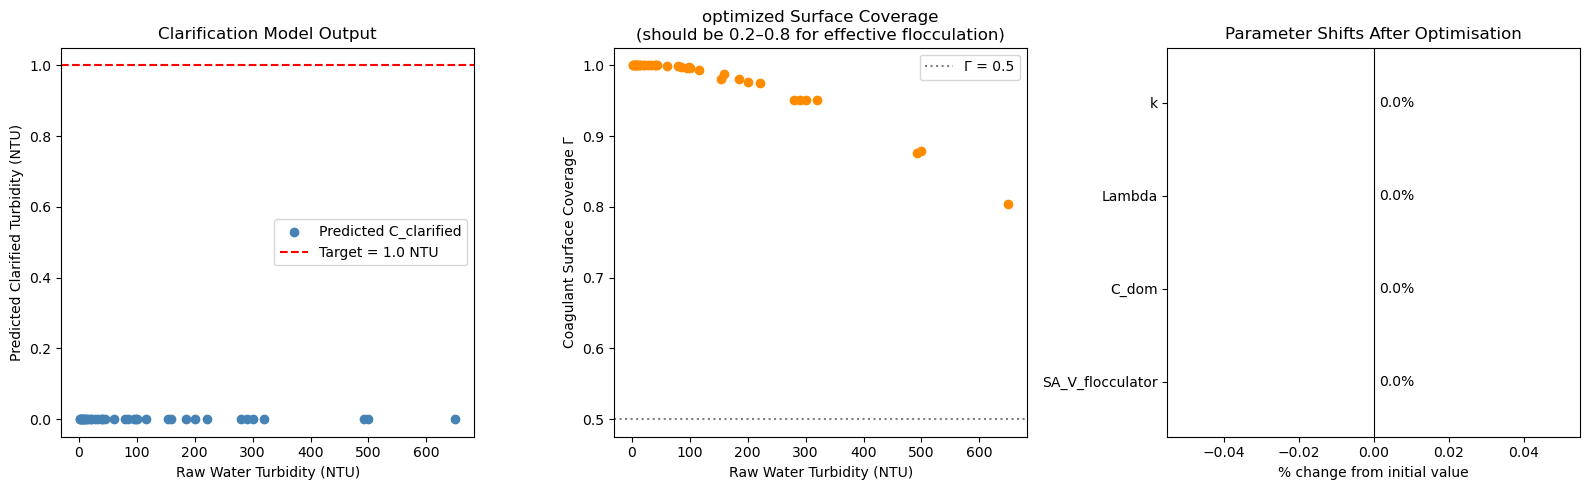

In [203]:
# ============================================================
# CELL 7 – Plots
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Clarified turbidity vs raw turbidity ─────────────
ax = axes[0]
idx = np.argsort(C_raw_NTU)
ax.scatter(C_raw_NTU, C_clarified_NTU, label="Predicted C_clarified",
           color="steelblue", zorder=3)
ax.axhline(C_TARGET_NTU, color="red", linestyle="--",
           label=f"Target = {C_TARGET_NTU} NTU")
ax.set_xlabel("Raw Water Turbidity (NTU)")
ax.set_ylabel("Predicted Clarified Turbidity (NTU)")
ax.set_title("Clarification Model Output")
ax.legend()

# ── Plot 2: Γ (coagulant surface coverage) vs C_raw ─────────
R_clay = 1
C_coag_aq = 0

N_per_clay = ((C_coag_mgL * MGL_TO_KG_M3 - C_coag_aq) * R_P ** 3.0
                * RHO_P) / (R_C ** 3.0 * RHO_C * C_raw_NTU * NTU_TO_KG_M3)

Gamma = np.clip(1 - (1 - R_C ** 2.0 / (4.0 * R_P ** 2.0)) ** (N_per_clay * R_clay),
                            0.0, 1.0)

ax = axes[1]
ax.scatter(C_raw_NTU, Gamma, color="darkorange")
ax.set_xlabel("Raw Water Turbidity (NTU)")
ax.set_ylabel("Coagulant Surface Coverage Γ")
ax.set_title("optimized Surface Coverage\n(should be 0.2–0.8 for effective flocculation)")
ax.axhline(0.5, color="gray", linestyle=":", label="Γ = 0.5")
ax.legend()

# ── Plot 3: Parameter % change bar chart ─────────────────────
ax = axes[2]
names      = list(INIT.keys())
pct_change = [(optimized[n] - INIT[n]) / INIT[n] * 100 for n in names]
colors     = ["steelblue" if v >= 0 else "tomato" for v in pct_change]
bars = ax.barh(names, pct_change, color=colors)
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("% change from initial value")
ax.set_title("Parameter Shifts After Optimisation")
ax.invert_yaxis()

plt.tight_layout()
plt.show()
# plt.savefig("floc_results_v2.png", dpi=150, bbox_inches="tight")
# print("Figure saved → floc_results_v2.png")

In [ ]:
# ============================================================
# CELL 8 – Sanity check: trace through the model manually
#           for one data point (the first one) so you can
#           verify each step against the PDF equations.
# ============================================================

for i in range(len(C_raw_NTU)):
    print(f"\n── Manual trace for data point {i} ─────────────────────")
    craw  = C_raw_NTU[i]
    ccoag = C_coag_mgL[i]
    print(f"  C_raw  = {craw:.1f} NTU  = {craw*NTU_TO_KG_M3:.4e} kg/m³")
    print(f"  C_coag = {ccoag:.2f} mg/L = {ccoag*MGL_TO_KG_M3:.4e} kg/m³")

    k1 = RHO_P * R_P / (4 * RHO_C * R_C)
    km  = optimized["k"]
    # rf  = optimized["r_floc"]
    # cfb = optimized["C_floc_blanket"]

    craw_si  = craw  * NTU_TO_KG_M3
    ccoag_si = ccoag * MGL_TO_KG_M3
    gamma = min(k1 * ccoag_si / craw_si, 1.0)

    C_coag_aq = 0
    n_per_clay = ((ccoag_si - C_coag_aq) * R_P ** 3.0
                    * RHO_P) / (R_C ** 3.0 * RHO_C * craw_si)
    # FIXME: Replace `gamma` and `k1` with alpha

    if gamma < 1 - 1e-3:
        continue

    k_pf_val = (3/(2*PI*km*G*THETA_T)) * ((RHO_P*PI/6)**(2/3))
    c_floc = (craw_si**(-2/3) + gamma/k_pf_val)**(-1.5)

    # phi = cfb / RHO_P
    # mf  = RHO_P * (4/3) * PI * rf**3
    # lam = (mf/cfb)**(1/3)
    lam = optimized["Lambda"]
    p   = gamma * PI * (3*PHI_FLOC/(4*PI))**(2/3)
    nb  = H_FF / lam
    c_clar = c_floc * (1-p)**nb

    print(f"\n  k_1                = {k1:.4f}  (dimensionless)")
    print(f"  N_perClay         = {n_per_clay:.4f}  coagulant particles/clay particle")
    print(f"  Γ (coverage)       = {gamma:.4f}  (should be 0–1)")
    print(f"  k_pf               = {k_pf_val:.4e}  (kg/m³)^(2/3)")
    print(f"  C_flocculated      = {c_floc:.4e} kg/m³ = {c_floc/NTU_TO_KG_M3:.2f} NTU")
    # print(f"  φ_floc             = {phi:.4e}  (volume fraction of floc blanket)")
    # print(f"  m_floc             = {mf:.4e} kg")
    # print(f"  Λ (spacing)        = {lam*100:.2f} cm")
    print(f"  p (removal/box)    = {p:.4e}")
    print(f"  n_boxes (h_ff/Λ)   = {nb:.1f}")
    print(f"  C_clarified        = {c_clar:.4e} kg/m³ = {c_clar/NTU_TO_KG_M3:.3f} NTU")
    print(f"  Target             = {C_TARGET_NTU:.1f} NTU")


── Manual trace for data point 0 ─────────────────────
  C_raw  = 1.9 NTU  = 2.8224e-03 kg/m³
  C_coag = 6.00 mg/L = 6.0000e-03 kg/m³

  k_1                = 44.4249  (dimensionless)
  N_perClay         = 2285232.3564  coagulant particles/clay particle
  Γ (coverage)       = 1.0000  (should be 0–1)
  k_pf               = 2.5317e-03  (kg/m³)^(2/3)
  C_flocculated      = 1.0650e-04 kg/m³ = 0.07 NTU
  p (removal/box)    = 3.4131e-01
  n_boxes (h_ff/Λ)   = 100.0
  C_clarified        = 7.8583e-23 kg/m³ = 0.000 NTU
  Target             = 1.0 NTU

── Manual trace for data point 1 ─────────────────────
  C_raw  = 2.2 NTU  = 3.2928e-03 kg/m³
  C_coag = 7.00 mg/L = 7.0000e-03 kg/m³

  k_1                = 44.4249  (dimensionless)
  N_perClay         = 2285232.3564  coagulant particles/clay particle
  Γ (coverage)       = 1.0000  (should be 0–1)
  k_pf               = 2.5317e-03  (kg/m³)^(2/3)
  C_flocculated      = 1.0828e-04 kg/m³ = 0.07 NTU
  p (removal/box)    = 3.4131e-01
  n_boxes (h_ff/Λ)

In [ ]:
# ============================================================
# CELL X – Invert model to get required coagulant dose
# ============================================================
from scipy.optimize import brentq

predicted_dose_mgL = []

for i in range(N):
    print(f"---Point {i}-------------")
    c_raw  = C_raw_mass[i]
    target = C_target[i]/NTU_TO_KG_M3

    def residual(dose_si):
        C_flocculated, C_pred = floc_clarify_model(
            np.array([c_raw]),
            np.array([dose_si]),
            optimized
        )
        print(f"C_raw: {c_raw/NTU_TO_KG_M3:.8f}")
        print(f"C_coag: {dose_si / MGL_TO_KG_M3:.8f}")
        print(f"C_flocculated: {C_flocculated[0]/NTU_TO_KG_M3:.8f}")
        print(f"C_pred: {C_pred[0]/NTU_TO_KG_M3:.8f}")
        return C_pred[0]/NTU_TO_KG_M3 - target

    # Search bounds in SI (kg/m³), converted from a wide mg/L range
    lo = 0.001 * MGL_TO_KG_M3   # 0.01 mg/L
    hi = 100.0 * MGL_TO_KG_M3  # 100  mg/L

    try:
        dose_si = brentq(residual, lo, hi, xtol=1e-12, rtol=1e-10)
        predicted_dose_mgL.append(dose_si / MGL_TO_KG_M3)
    except ValueError:
        # No sign change found — target may be unreachable in [lo, hi]
        print(f"  Point {i}: no solution found in [{lo/MGL_TO_KG_M3}, {hi/MGL_TO_KG_M3}] mg/L")
        predicted_dose_mgL.append(np.nan)

predicted_dose_mgL = np.array(predicted_dose_mgL)

---Point 0-------------
C_raw: 1.92000000
C_coag: 0.00100000
C_flocculated: 1.92000000
C_pred: 1.92000000
C_raw: 1.92000000
C_coag: 100.00000000
C_flocculated: 0.07245048
C_pred: 0.00000000
C_raw: 1.92000000
C_coag: 47.91718750
C_flocculated: 0.07245048
C_pred: 0.00000000
C_raw: 1.92000000
C_coag: 22.96083984
C_flocculated: 0.07245048
C_pred: 0.00000000
C_raw: 1.92000000
C_coag: 11.00258993
C_flocculated: 0.07245048
C_pred: 0.00000000
C_raw: 1.92000000
C_coag: 5.27259517
C_flocculated: 0.07245048
C_pred: 0.00000000
C_raw: 1.92000000
C_coag: 2.52697269
C_flocculated: 0.07245048
C_pred: 0.00000000
C_raw: 1.92000000
C_coag: 1.21136191
C_flocculated: 0.07257498
C_pred: 0.00000000
C_raw: 1.92000000
C_coag: 0.58096508
C_flocculated: 1.92000000
C_pred: 1.92000000
C_raw: 1.92000000
C_coag: 0.89616350
C_flocculated: 1.92000000
C_pred: 1.92000000
C_raw: 1.92000000
C_coag: 1.05376271
C_flocculated: 0.09467324
C_pred: 0.00000000
C_raw: 1.92000000
C_coag: 0.97167978
C_flocculated: 1.92000000
C_pred

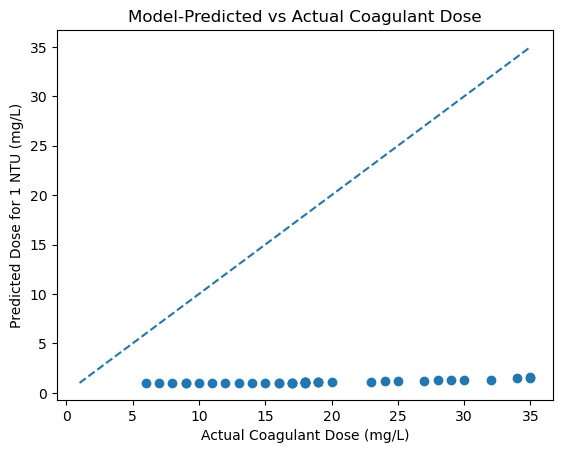

In [ ]:
# ============================================================
# CELL Y – Scatter plot comparison
# ============================================================

plt.figure()

plt.scatter(C_coag_mgL, predicted_dose_mgL)

# Optional: 1:1 reference line
min_val = min(C_coag_mgL.min(), predicted_dose_mgL.min())
max_val = max(C_coag_mgL.max(), predicted_dose_mgL.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Coagulant Dose (mg/L)")
plt.ylabel("Predicted Dose for 1 NTU (mg/L)")
plt.title("Model-Predicted vs Actual Coagulant Dose")

plt.show()

[1.00045948 1.0006492  1.00144233 1.00256235 1.00273497 1.0037405
 1.00485549 1.00668294 1.0068476  1.00985637 1.01087433 1.01543148
 1.01551824 1.02093738 1.02579576 1.03283166 1.03301048 1.03623428
 1.0513763  1.06881398 1.0730976  1.08304962 1.08570111 1.08707312
 1.10081202 1.13665627 1.14126162 1.16431446 1.17908797 1.1984976
 1.25312211 1.26239152 1.27166363 1.29021536 1.45006395 1.45750873
 1.59720943]
[1.         0.99999999 1.         1.00000011 0.99999998 1.00000001
 1.         0.99999995 1.         0.99999998 1.         1.
 1.         1.         1.         0.99999998 0.99999998 1.
 1.         1.         1.00000001 1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.        ]


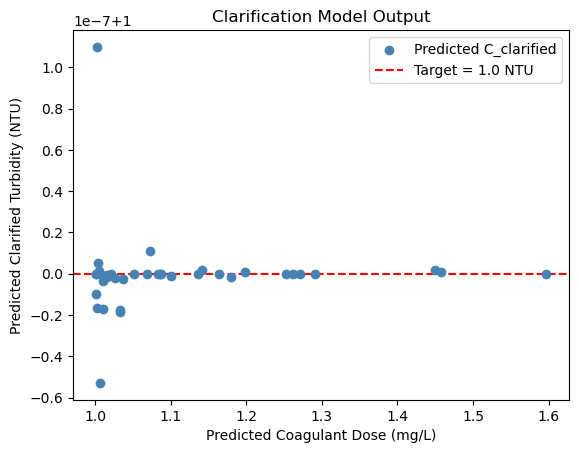

In [ ]:
influent_NTU = 1.9
C_influent_mass = np.full(10, influent_NTU * NTU_TO_KG_M3)
# C_c_mass = np.linspace(0, 1, 10)

print(predicted_dose_mgL)
C_f, C_c = floc_clarify_model(C_raw_mass, predicted_dose_mgL * MGL_TO_KG_M3, optimized)
C_clarified_NTU = C_c / NTU_TO_KG_M3
C_flocculated_NTU = C_f / NTU_TO_KG_M3
print(C_clarified_NTU)

plt.figure()

plt.scatter(predicted_dose_mgL, C_clarified_NTU, label="Predicted C_clarified",
           color="steelblue", zorder=3)
plt.axhline(C_TARGET_NTU, color="red", linestyle="--",
           label=f"Target = {C_TARGET_NTU} NTU")
plt.xlabel("Predicted Coagulant Dose (mg/L)")
plt.ylabel("Predicted Clarified Turbidity (NTU)")
plt.title(f"Clarification Model Output")
plt.legend()